# 2. From waveform to pitch: tuning, mixing, resampling

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-GITHUB-USER/chord-recognition-book/blob/main/notebooks/02_waveform_to_pitch.ipynb)

> **Paper ↔ code.** Section I (Eqs. 1–3) explains 12-tone equal temperament; Section II-A (Eq. 4) turns a stereo CD track into a mono signal at 22 050 Hz with floating-point samples. Functions: `features.stereo_to_mono`, `features.pcm16_to_float`, `features.load_audio`.

Nothing in this notebook needs the RWC audio — we synthesise our own sounds with `chordlab.synth`, so you can learn the front end before the download finishes.

In [1]:
# --- Setup: works locally (run from anywhere inside the repository) and on Google Colab ---
import os, sys, pathlib, subprocess

REPO = "YOUR-GITHUB-USER/chord-recognition-book"   # <-- change this after forking

if "google.colab" in sys.modules:
    root = pathlib.Path("/content") / REPO.split("/")[1]
    if not root.exists():
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", str(root)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(root)], check=True)
else:
    root = pathlib.Path.cwd().resolve()
    while not (root / "chordlab").exists() and root != root.parent:
        root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import IPython.display as ipd

import chordlab
from chordlab import data, features, templates, hmm, evaluate, midi_chords, synth, plots

plt.rcParams["figure.figsize"] = (11, 3.5)
plt.rcParams["figure.dpi"] = 110
print(f"chordlab {chordlab.__version__} loaded from {root}")
print("data folder:", data.data_root())

chordlab 0.1.0 loaded from /home/claude/chord-recognition-book
data folder: /home/claude/chord-recognition-book/data


## 2.1 Twelve equal steps to the octave

Western instruments are tuned in **12-tone equal temperament (12-TET)**: every semitone multiplies the frequency by the same ratio, so that twelve steps double the frequency:

$$ f_\text{ratio} = 2^{1/12} \approx 1.05946 \qquad\qquad (1) $$
$$ f_\text{Do}(\text{octave } n+1) = 2\, f_\text{Do}(\text{octave } n) \qquad (2) $$

Equal temperament is a compromise. A *just* perfect fifth has the ratio 3:2, but seven equal semitones give

$$ \frac{f_\text{Sol}}{f_\text{Do}} = 2^{7/12} \approx 1.49831 \qquad (3) $$

Let us compute how far each equal-tempered interval is from the simple ratios the ear likes, in per cent and in **cents** (1 cent = 1/100 of a semitone).

In [2]:
ratio = 2 ** (1 / 12)
print(f"semitone ratio 2^(1/12) = {ratio:.5f}")

just = {"unison": 1/1, "major second": 9/8, "major third": 5/4, "perfect fourth": 4/3,
        "perfect fifth": 3/2, "major sixth": 5/3, "octave": 2/1}
steps = {"unison": 0, "major second": 2, "major third": 4, "perfect fourth": 5, "perfect fifth": 7, "major sixth": 9, "octave": 12}
rows = []
for name, r_just in just.items():
    r_et = 2 ** (steps[name] / 12)
    rows.append({"interval": name, "semitones": steps[name], "just ratio": r_just, "12-TET ratio": r_et,
                 "deviation %": 100 * (r_et - r_just) / r_just, "deviation cents": 1200 * np.log2(r_et / r_just)})
pd.DataFrame(rows).round(4)

semitone ratio 2^(1/12) = 1.05946


,interval,semitones,just ratio,12-TET ratio,deviation %,deviation cents
0,unison,0,1.0000,1.0000,0.0000,0.0000
1,major second,2,1.1250,1.1225,-0.2256,-3.9100
2,major third,4,1.2500,1.2599,0.7937,13.6863
3,perfect fourth,5,1.3333,1.3348,0.1130,1.9550
4,perfect fifth,7,1.5000,1.4983,-0.1129,-1.9550
5,major sixth,9,1.6667,1.6818,0.9076,15.6413
6,octave,12,2.0000,2.0000,0.0000,0.0000


The equal-tempered fifth is **about 0.11 % (2 cents) narrow** — inaudible to most listeners, but the major third is 14 cents (0.8 %) *wide*, which is what makes some chords "shimmer". (The paper quotes 0.17 % for the fifth; the exact value from Eq. 3 is $100\,(1.5 - 2^{7/12})/1.5 \approx 0.113\%$.) Real instruments deviate further: pianos are *stretch-tuned*, singers slide, guitars drift. This is why the paper's chroma features must tolerate small pitch deviations — a CQT bin is a semitone wide, not a razor.

## 2.2 Note names, MIDI numbers and Hertz

`librosa` handles the bookkeeping: MIDI note 69 = A4 = 440 Hz, and every semitone adds one MIDI number.

In [3]:
for note in ["C1", "C2", "A4", "C4", "C8"]:
    print(f"{note:3s}  MIDI {librosa.note_to_midi(note):3d}   {librosa.note_to_hz(note):9.2f} Hz")
print(f"\nThe paper's CQT starts at f_min = C1 = {librosa.note_to_hz('C1'):.2f} Hz")

C1   MIDI  24       32.70 Hz
C2   MIDI  36       65.41 Hz
A4   MIDI  69      440.00 Hz
C4   MIDI  60      261.63 Hz
C8   MIDI 108     4186.01 Hz

The paper's CQT starts at f_min = C1 = 32.70 Hz


## 2.3 A toy band

`chordlab.synth` renders chord progressions with two timbres that mirror Fig. 1 of the paper: a *flute* (almost a pure sine) and a *piano* (a stack of decaying harmonics). Because we generate the audio, we also know its ground truth exactly — a luxury we will not have with real recordings.

In [4]:
sr = features.SR
y, gt_intervals, gt_labels = synth.render_progression(synth.DEMO_PROGRESSION, durations=2.0, sr=sr, timbre="piano")
print(f"{len(y) / sr:.1f} s of audio, {len(gt_labels)} chords:", gt_labels)
ipd.Audio(y, rate=sr)

16.0 s of audio, 8 chords: ['C:maj', 'G:maj', 'A:min', 'F:maj', 'D:min', 'G:maj', 'C:maj', 'E:min']


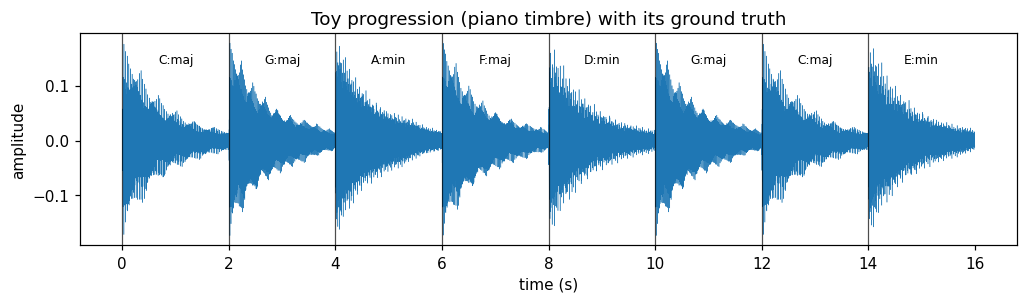

In [5]:
fig, ax = plt.subplots(figsize=(11, 2.5))
t = np.arange(len(y)) / sr
ax.plot(t, y, lw=0.3)
plots.overlay_segments(ax, gt_intervals, gt_labels, y=0.9 * y.max(), color="k")
ax.set(xlabel="time (s)", ylabel="amplitude", title="Toy progression (piano timbre) with its ground truth")
plt.show()

## 2.4 Stereo → mono → 22 050 Hz → floats (paper §II-A)

CD audio is stereo, 16-bit integer PCM at 44 100 Hz. The paper (Eq. 4) averages the two channels,

$$ y_\text{mono}[n] = \frac{x_\text{left}[n] + x_\text{right}[n]}{2}, \qquad (4) $$

resamples to 22 050 Hz to halve the computation, and scales the integers $[-32768, 32767]$ to floats in $[-1, 1]$. Let us *fake* a CD track from our toy signal — write a stereo 16-bit WAV at 44.1 kHz — and then undo it the way the paper does.

In [6]:
import soundfile as sf

y44 = librosa.resample(y, orig_sr=sr, target_sr=44100)
stereo = np.stack([y44, 0.6 * y44], axis=1)                    # a slightly unbalanced stereo image, shape (n, 2)
sf.write("toy_cd.wav", stereo, 44100, subtype="PCM_16")
print(sf.info("toy_cd.wav"))

# Step by step, as in the paper ...
x_int, sr_in = sf.read("toy_cd.wav", dtype="int16")            # 16-bit integers, shape (n, 2)
print("\ninteger range in file:", x_int.min(), x_int.max())
x_float = features.pcm16_to_float(x_int)                       # -> [-1, 1]
mono = features.stereo_to_mono(x_float)                        # Eq. (4)
mono_22k = librosa.resample(mono, orig_sr=sr_in, target_sr=22050)
print(f"mono at 22.05 kHz: {len(mono_22k)} samples, range [{mono_22k.min():.3f}, {mono_22k.max():.3f}]")

# ... and in one line, which is what the rest of the book uses:
y_loaded, sr_loaded = features.load_audio("toy_cd.wav", sr=22050)
print(f"features.load_audio -> {len(y_loaded)} samples at {sr_loaded} Hz; max abs difference to the manual path: {np.abs(y_loaded - mono_22k).max():.2e}")

toy_cd.wav
samplerate: 44100 Hz
channels: 2
duration: 16.000 s
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]

integer range in file: -5673 5820
mono at 22.05 kHz: 352800 samples, range [-0.138, 0.142]
features.load_audio -> 352800 samples at 22050 Hz; max abs difference to the manual path: 0.00e+00


Why is 22 050 Hz enough? The highest CQT bin the paper needs is below 4 kHz (B7 ≈ 3951 Hz) and the Nyquist frequency at 22 050 Hz is 11 025 Hz. Everything above is cymbals and air, irrelevant for harmony and — as the paper will show — actively harmful.

## 2.5 Frames

Chords are not detected sample by sample. The signal is cut into **frames**; with a hop size of 2048 samples at 22 050 Hz every chroma vector represents about 93 ms of music. All later notebooks share these constants from `chordlab.features`.

In [7]:
print(f"sample rate {features.SR} Hz, hop {features.HOP_LENGTH} samples -> {features.HOP_LENGTH / features.SR * 1000:.1f} ms per frame, "
      f"{features.SR / features.HOP_LENGTH:.2f} frames per second")
print(f"a 2-second chord spans about {2 * features.SR / features.HOP_LENGTH:.0f} frames")

sample rate 22050 Hz, hop 2048 samples -> 92.9 ms per frame, 10.77 frames per second
a 2-second chord spans about 22 frames


## Exercises

1. Change the toy progression to `["C:maj", "C#:maj", "D:maj"]` and listen. Then compute the frequency of the root of each chord in octave 3 (`synth.midi_of_chord`).
2. At what hop size would a chroma frame last exactly one beat at 120 BPM? What is the trade-off of such long frames?
3. Average the channels of a stereo file where one channel is the *inverse* of the other (`stereo = np.stack([y44, -y44])`). What happens to Eq. 4, and why do audio engineers care about *phase*?